In [5]:
# for sumarry overview of the data
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.io as pio
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
import webbrowser
import os
import plotly.graph_objects as go

In [3]:
#Load the dataset
data=pd.read_csv("heart-disease.csv")

In [4]:
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [5]:
print(data)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   3       145   233    1        0      150      0      2.3   
1     37    1   2       130   250    0        1      187      0      3.5   
2     41    0   1       130   204    0        0      172      0      1.4   
3     56    1   1       120   236    0        1      178      0      0.8   
4     57    0   0       120   354    0        1      163      1      0.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   57    0   0       140   241    0        1      123      1      0.2   
299   45    1   3       110   264    0        1      132      0      1.2   
300   68    1   0       144   193    1        1      141      0      3.4   
301   57    1   0       130   131    0        1      115      1      1.2   
302   57    0   1       130   236    0        0      174      0      0.0   

     slope  ca  thal  target  
0        0   0     1       1  
1        0   0     2     

In [7]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [8]:
data.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [10]:
#to see the type of the data
type(data)

pandas.DataFrame

In [11]:
# to display the summary of the data
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [12]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [2]:
# for numerical calculations
import numpy as np

In [8]:
data.head(10)

NameError: name 'data' is not defined

In [16]:
# to check any null values 
print(data.isnull())
# will give sum of null values in each column
print(data.isnull().sum()) 

       age    sex     cp  trestbps   chol    fbs  restecg  thalach  exang  \
0    False  False  False     False  False  False    False    False  False   
1    False  False  False     False  False  False    False    False  False   
2    False  False  False     False  False  False    False    False  False   
3    False  False  False     False  False  False    False    False  False   
4    False  False  False     False  False  False    False    False  False   
..     ...    ...    ...       ...    ...    ...      ...      ...    ...   
298  False  False  False     False  False  False    False    False  False   
299  False  False  False     False  False  False    False    False  False   
300  False  False  False     False  False  False    False    False  False   
301  False  False  False     False  False  False    False    False  False   
302  False  False  False     False  False  False    False    False  False   

     oldpeak  slope     ca   thal  target  
0      False  False  False  Fal

In [17]:
df=pd.read_csv("winemag-data_first150k.csv")

In [18]:
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [19]:
print(data)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   3       145   233    1        0      150      0      2.3   
1     37    1   2       130   250    0        1      187      0      3.5   
2     41    0   1       130   204    0        0      172      0      1.4   
3     56    1   1       120   236    0        1      178      0      0.8   
4     57    0   0       120   354    0        1      163      1      0.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   57    0   0       140   241    0        1      123      1      0.2   
299   45    1   3       110   264    0        1      132      0      1.2   
300   68    1   0       144   193    1        1      141      0      3.4   
301   57    1   0       130   131    0        1      115      1      1.2   
302   57    0   1       130   236    0        0      174      0      0.0   

     slope  ca  thal  target  
0        0   0     1       1  
1        0   0     2     

In [20]:
print(df)

        Unnamed: 0 country                                        description  \
0                0      US  This tremendous 100% varietal wine hails from ...   
1                1   Spain  Ripe aromas of fig, blackberry and cassis are ...   
2                2      US  Mac Watson honors the memory of a wine once ma...   
3                3      US  This spent 20 months in 30% new French oak, an...   
4                4  France  This is the top wine from La Bégude, named aft...   
...            ...     ...                                                ...   
150925      150925   Italy  Many people feel Fiano represents southern Ita...   
150926      150926  France  Offers an intriguing nose with ginger, lime an...   
150927      150927   Italy  This classic example comes from a cru vineyard...   
150928      150928  France  A perfect salmon shade, with scents of peaches...   
150929      150929   Italy  More Pinot Grigios should taste like this. A r...   

                           

In [21]:
df

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,variety,winery
0,0,US,This tremendous 100% varietal wine hails from ...,Martha's Vineyard,96,235.0,California,Napa Valley,Napa,Cabernet Sauvignon,Heitz
1,1,Spain,"Ripe aromas of fig, blackberry and cassis are ...",Carodorum Selección Especial Reserva,96,110.0,Northern Spain,Toro,NaN,Tinta de Toro,Bodega Carmen Rodríguez
2,2,US,Mac Watson honors the memory of a wine once ma...,Special Selected Late Harvest,96,90.0,California,Knights Valley,Sonoma,Sauvignon Blanc,Macauley
3,3,US,"This spent 20 months in 30% new French oak, an...",Reserve,96,65.0,Oregon,Willamette Valley,Willamette Valley,Pinot Noir,Ponzi
4,4,France,"This is the top wine from La Bégude, named aft...",La Brûlade,95,66.0,Provence,Bandol,NaN,Provence red blend,Domaine de la Bégude
...,...,...,...,...,...,...,...,...,...,...,...
150925,150925,Italy,Many people feel Fiano represents southern Ita...,NaN,91,20.0,Southern Italy,Fiano di Avellino,NaN,White Blend,Feudi di San Gregorio
150926,150926,France,"Offers an intriguing nose with ginger, lime an...",Cuvée Prestige,91,27.0,Champagne,Champagne,NaN,Champagne Blend,H.Germain
150927,150927,Italy,This classic example comes from a cru vineyard...,Terre di Dora,91,20.0,Southern Italy,Fiano di Avellino,NaN,White Blend,Terredora
150928,150928,France,"A perfect salmon shade, with scents of peaches...",Grand Brut Rosé,90,52.0,Champagne,Champagne,NaN,Champagne Blend,Gosset


In [22]:
df.isnull().sum()

Unnamed: 0         0
country            5
description        0
designation    45735
points             0
price          13695
province           5
region_1       25060
region_2       89977
variety            0
winery             0
dtype: int64

In [23]:
df.isnull()

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,variety,winery
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...
150925,False,False,False,True,False,False,False,False,True,False,False
150926,False,False,False,False,False,False,False,False,True,False,False
150927,False,False,False,False,False,False,False,False,True,False,False
150928,False,False,False,False,False,False,False,False,True,False,False


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150930 entries, 0 to 150929
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Unnamed: 0   150930 non-null  int64  
 1   country      150925 non-null  str    
 2   description  150930 non-null  str    
 3   designation  105195 non-null  str    
 4   points       150930 non-null  int64  
 5   price        137235 non-null  float64
 6   province     150925 non-null  str    
 7   region_1     125870 non-null  str    
 8   region_2     60953 non-null   str    
 9   variety      150930 non-null  str    
 10  winery       150930 non-null  str    
dtypes: float64(1), int64(2), str(8)
memory usage: 12.7 MB


In [25]:
df.head()

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,variety,winery
0,0,US,This tremendous 100% varietal wine hails from ...,Martha's Vineyard,96,235.0,California,Napa Valley,Napa,Cabernet Sauvignon,Heitz
1,1,Spain,"Ripe aromas of fig, blackberry and cassis are ...",Carodorum Selección Especial Reserva,96,110.0,Northern Spain,Toro,NaN,Tinta de Toro,Bodega Carmen Rodríguez
2,2,US,Mac Watson honors the memory of a wine once ma...,Special Selected Late Harvest,96,90.0,California,Knights Valley,Sonoma,Sauvignon Blanc,Macauley
3,3,US,"This spent 20 months in 30% new French oak, an...",Reserve,96,65.0,Oregon,Willamette Valley,Willamette Valley,Pinot Noir,Ponzi
4,4,France,"This is the top wine from La Bégude, named aft...",La Brûlade,95,66.0,Provence,Bandol,NaN,Provence red blend,Domaine de la Bégude


In [27]:
df['price']=df['price'].replace(np.nan,df['price'].mean())

In [29]:
df.isnull().sum()

Unnamed: 0         0
country            5
description        0
designation    45735
points             0
price              0
province           5
region_1       25060
region_2       89977
variety            0
winery             0
dtype: int64

In [31]:
print(df['price'])

0         235.0
1         110.0
2          90.0
3          65.0
4          66.0
          ...  
150925     20.0
150926     27.0
150927     20.0
150928     52.0
150929     15.0
Name: price, Length: 150930, dtype: float64


In [5]:
# matplotlib is used for basic visualization library, pyplot is a sublibrary from matplotlib
# seaborn is used for meduim,advanced visualization 
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# for an interactive graph, visualization use ploty. Tt is more advanced than seaborn
import plotly.express as ps

In [10]:
# matplotlib
xpoints=np.array([0,6])
ypoints=np.array([0,250])

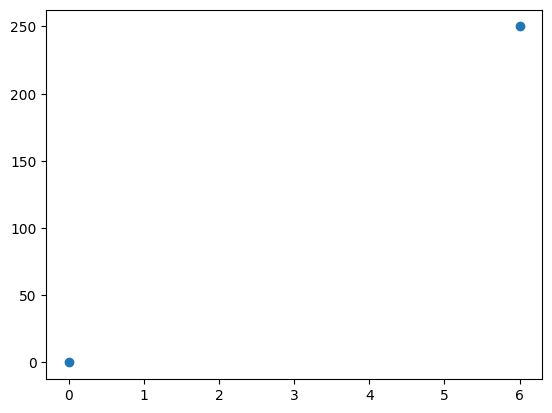

In [13]:
plt.plot(xpoints,ypoints,'o') # will display as a dot if there is  'o' than it will displayed in line
plt.show()

In [14]:
# to plot multiple values
apoints=np.array([1,2,6,8])
bpoints=np.array([3,8,1,10])

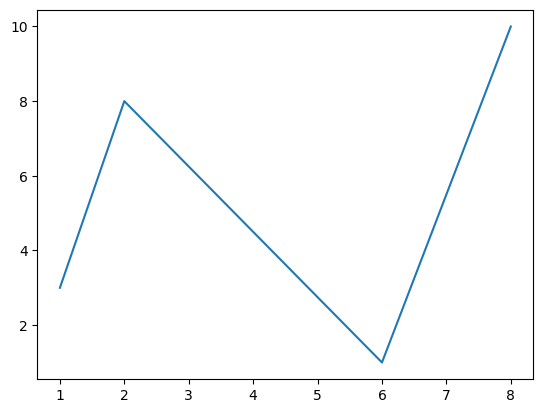

In [15]:
plt.plot(apoints,bpoints)
plt.show()

In [3]:
# to plot a pie chart
y=np.array([35,25,25,15])

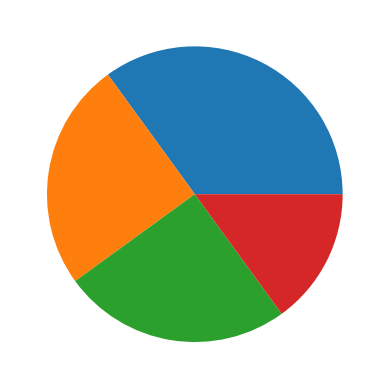

In [6]:
plt.pie(y)
plt.show()

In [9]:
# to plot an histogram
# np.random.normal(mean(start value), standard_deviation(how many), number_of_values(kitne talak))
x=np.random.normal(170,10,250)
print(x)

[187.51380501 186.86939934 166.42248852 168.25792017 158.46052455
 162.69734534 170.85140904 166.17995255 180.9689366  185.5445529
 183.01981086 165.49334312 183.92988075 155.90247744 152.15117552
 171.14995613 159.46452461 167.15494353 163.71656692 185.73772674
 160.92453819 180.46540966 169.87272187 167.79053167 158.73567188
 174.88772338 165.97058731 158.35400624 157.90512982 170.38801868
 187.06285705 181.77198117 189.4500262  172.61835856 186.80624457
 150.28050303 159.76536973 167.53909897 165.50456898 168.10502621
 174.47116359 181.94144563 173.13310888 164.17527085 158.69539027
 163.80903007 179.97799024 165.7197016  161.35876047 157.96026201
 165.44581056 171.0702812  168.99746988 180.23702453 168.68942156
 151.75453575 165.39916825 181.03059414 163.70986793 181.3849697
 168.8135286  156.70797451 169.11152068 164.95409382 173.10038901
 166.73699961 176.30896219 157.06889936 169.99710216 193.47718712
 161.46433786 166.44967692 163.56553534 169.80890943 159.19274544
 178.0940871

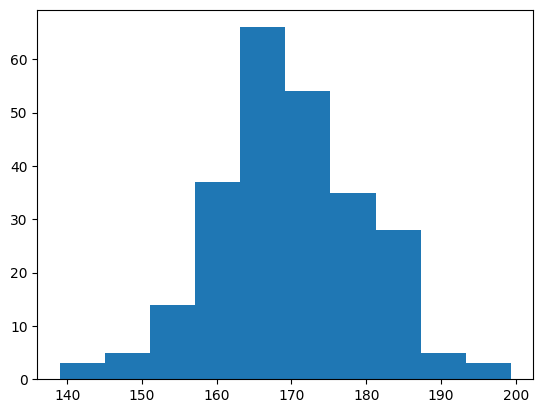

In [10]:
plt.hist(x)
plt.show()

C:\Users\Akshata Puthran\AppData\Local\Temp\ipykernel_15100\1230270085.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot([0,1,2,3,4,5])


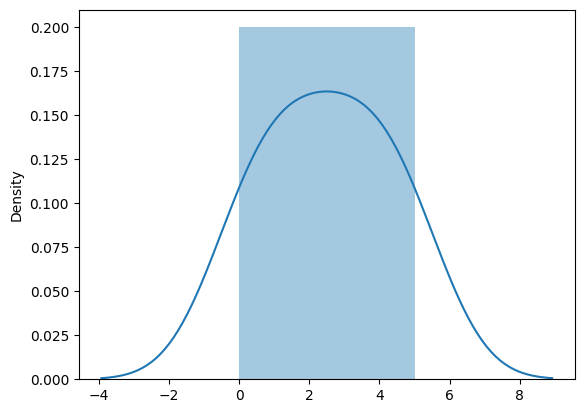

In [13]:
#seaborn, it includes mixture of multiple graphs, mixture of line chart or bar chart etc,
# it is a statiscal graph it combines statistics a gives visualization
sns.distplot([0,1,2,3,4,5])
plt.show()

In [14]:
#sklearn(machine learning model)
from sklearn.model_selection import train_test_split # to split the data 
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import mean_squared_erroe,r2_score 

ModuleNotFoundError: No module named 'sklearn'

In [15]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

NameError: name 'train_test_split' is not defined

In [16]:
# nltk natural language processing library, sentiment analysis, to import
# sentiment analysis : read sentences and give reviews positive or negative review
# import nltk

In [3]:
apps_df=pd.read_csv('Play Store Data.csv')
reviews_df=pd.read_csv('User Reviews.csv')

In [6]:
html_file_path="./"
if not os.path.exists(html_file_path):
    os.makedirs(html_file_path)

In [7]:
plot_containers=""

In [10]:
def save_plot_html(fig,filename,insight):
    global plot_containers
    filepath=os.path.join(html_file_path,filename)
    html_content=pio.to_html(fig,full_html=False,include_plotlyjs='inline')
    plot_containers+=f"""<div class ="plot-containers" id="{filename}')" onclick="openPlot('{filename}')">
    <div class="plot"> {html_content}</div> <div class="insights"> {insight}</div></div>"""
    fig.write_html(filepath,full_html=False,include_plotlyjs='inline')

In [11]:
plot_width=400
plot_height=300
plot_bg_color='black'
text_color='white'
title_font={'size':16}
axis_font={'size':12}

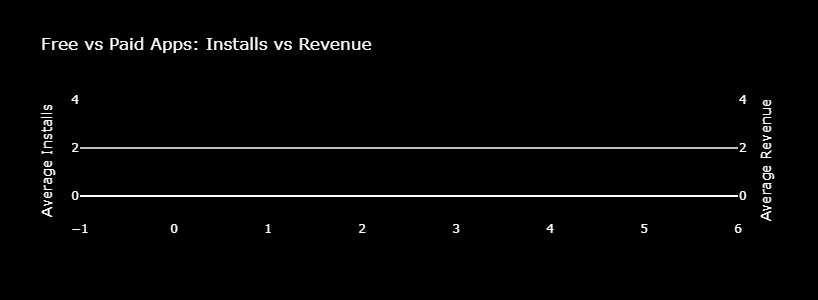

In [14]:
# 🔹 Clean Price
apps_df['Price'] = apps_df['Price'].astype(str)\
    .str.replace('$', '', regex=True)
apps_df['Price'] = pd.to_numeric(apps_df['Price'], errors='coerce')

# 🔹 Create Revenue
apps_df['Revenue'] = apps_df['Price'] * apps_df['Installs']
apps_df['Android Ver'] = (
    apps_df['Android Ver']
    .astype(str)
    .str.extract(r'(\d+\.?\d*)')[0]
)
apps_df['Android Ver'] = pd.to_numeric(apps_df['Android Ver'], errors='coerce')

# 🔹 Clean Installs
apps_df['Installs'] = apps_df['Installs'].astype(str)\
    .str.replace('[+,]', '', regex=True)
apps_df['Installs'] = pd.to_numeric(apps_df['Installs'], errors='coerce')

# 🔹 Convert Size
def convert_size(size):
    if isinstance(size, str):
        if 'M' in size:
            return float(size.replace('M',''))
        elif 'k' in size:
            return float(size.replace('k','')) / 1024
    return np.nan

apps_df['Size_MB'] = apps_df['Size'].apply(convert_size)

# 🔹 Filters
df = apps_df[
    (apps_df['Installs'] > 10000) &
    (apps_df['Revenue'] > 10000) &
    (apps_df['Android Ver'] > 4.0) &
    (apps_df['Size_MB'] > 15) &
    (apps_df['Content Rating'] == 'Everyone') &
    (apps_df['App'].str.len() <= 30)
].copy()

# 🔹 Top 3 categories
top3 = df.groupby('Category')['Installs'].sum().nlargest(3).index
df = df[df['Category'].isin(top3)]

# 🔹 Grouping
grouped = df.groupby('Type').agg({
    'Installs': 'mean',
    'Revenue': 'mean'
}).reset_index()

# 🔹 Dual Axis
import plotly.graph_objects as go

tsk6 = go.Figure()

tsk6.add_trace(go.Bar(
    x=grouped['Type'],
    y=grouped['Installs'],
    name='Avg Installs'
))

tsk6.add_trace(go.Scatter(
    x=grouped['Type'],
    y=grouped['Revenue'],
    name='Avg Revenue',
    yaxis='y2',
    mode='lines+markers'
))

tsk6.update_layout(
    title="Free vs Paid Apps: Installs vs Revenue",
    yaxis=dict(title="Average Installs"),
    yaxis2=dict(title="Average Revenue", overlaying='y', side='right'),
    plot_bgcolor='black',
    paper_bgcolor='black',
    font_color='white',
    width=400,
    height=300
)

tsk6.show()

save_plot_html(
    tsk6,
    "Dual_Axis_Chart_6.html",
    "Comparison of installs and revenue for free vs paid apps."
)

In [13]:
apps_df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000.0,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0,19.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000.0,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000.0,Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0,8.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50000000.0,Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2,25.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,100000.0,Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4,2.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,5000.0,Free,0,Everyone,Education,"July 25, 2017",1.48,4.1,53.0
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100.0,Free,0,Everyone,Education,"July 6, 2018",1,4.1,3.6
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,1000.0,Free,0,Everyone,Medical,"January 20, 2017",1,2.2,9.5
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,1000.0,Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,NaN,NaN
